# 06 — Sim Success Classification (Early Season)

Predict whether a season will result in a successful harvest **before** it ends.

**Method:** Use only the first N days of each season (30 / 60 / 90), same approach as notebook 04.  
**Why:** Full-season features like `max_dvs` and `max_tagp` leak information — they're only known after harvest.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
import duckdb
from pathlib import Path
from sklearn.metrics import (
    classification_report, roc_auc_score, RocCurveDisplay
)

from src.data.loader import RAW_PATH

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
FIGS      = '../outputs/figures/'

## 1. Load data

In [2]:
CUTOFFS = [30, 60, 90]

def load_cutoff(n_days: int) -> pd.DataFrame:
    """Aggregate only the first n_days of each season."""
    return duckdb.query(f"""
        WITH season_start AS (
            SELECT
                latitude, longitude, elevation,
                crop_name, variety_name, year, wav_scenario, WAV,
                MIN(DATETIME::TIMESTAMP) AS start_ts,
                MAX(harvest_twso)        AS harvest_twso,
                MAX(sim_success)         AS sim_success
            FROM '{RAW_PATH}'
            GROUP BY latitude, longitude, elevation,
                     crop_name, variety_name, year, wav_scenario, WAV
        ),
        filtered AS (
            SELECT r.*
            FROM '{RAW_PATH}' r
            JOIN season_start s
              ON  r.latitude     = s.latitude
              AND r.longitude    = s.longitude
              AND r.crop_name    = s.crop_name
              AND r.year         = s.year
              AND r.wav_scenario = s.wav_scenario
            WHERE r.DATETIME::TIMESTAMP < s.start_ts + INTERVAL '{n_days} days'
        )
        SELECT
            f.latitude, f.longitude, f.elevation,
            f.crop_name, f.year, f.wav_scenario, f.WAV,
            MAX(f.harvest_twso)  AS harvest_twso,
            MAX(f.sim_success)   AS sim_success,
            AVG(f.AIR_TEMP)      AS mean_temp,
            SUM(f.PRECIP)        AS total_precip,
            AVG(f.AIR_HUMIDITY)  AS mean_humidity,
            AVG(f.RFTRA)         AS mean_rftra,
            MAX(f.LAI)           AS max_lai,
            MAX(f.TAGP)          AS max_tagp,
            MAX(f.DVS)           AS max_dvs,
            COUNT(DISTINCT DATE_TRUNC('day', f.DATETIME::TIMESTAMP)) AS season_days
        FROM filtered f
        GROUP BY f.latitude, f.longitude, f.elevation,
                 f.crop_name, f.year, f.wav_scenario, f.WAV
    """).df()

datasets = {}
for n in CUTOFFS:
    print(f'Loading: first {n} days...', end=' ')
    datasets[n] = load_cutoff(n)
    print(f'{len(datasets[n]):,} rows  |  success rate: {datasets[n]["sim_success"].mean():.1%}')

Loading: first 30 days... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 rows  |  success rate: 77.9%
Loading: first 60 days... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 rows  |  success rate: 77.9%
Loading: first 90 days... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 rows  |  success rate: 77.9%


## 2. Feature prep & train/test split

In [3]:
TARGET = 'sim_success'
TEST_YEARS = [2023, 2024]

with open(PROCESSED / 'crop_te_map.json') as f:
    crop_te_export = json.load(f)
global_mean = crop_te_export.pop('__global_mean__')
crop_te_map = crop_te_export

FEATURE_COLS = [
    'mean_temp', 'total_precip', 'mean_humidity', 'mean_rftra',
    'max_lai', 'max_tagp', 'max_dvs', 'season_days',
    'latitude', 'longitude', 'elevation', 'year', 'WAV', 'crop_te',
]

def prepare(df):
    df = df.copy()
    df['crop_te'] = df['crop_name'].map(crop_te_map).fillna(global_mean)
    train = df[~df['year'].isin(TEST_YEARS)]
    test  = df[ df['year'].isin(TEST_YEARS)]
    return (train[FEATURE_COLS], train[TARGET],
            test[FEATURE_COLS],  test[TARGET], test)

print('Ready.')

Ready.


## 3. Train classifiers (one per cutoff)

In [4]:
results = {}

for n in CUTOFFS:
    X_tr, y_tr, X_te, y_te, test_df = prepare(datasets[n])

    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    scale = neg / pos

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    auc     = roc_auc_score(y_te, y_proba)

    results[n] = {'model': model, 'y_te': y_te, 'y_pred': y_pred,
                  'y_proba': y_proba, 'auc': auc, 'test_df': test_df}
    print(f'Day {n:3d} | AUC={auc:.4f}  best_iter={model.best_iteration_}')

[LightGBM] [Info] Number of positive: 34013, number of negative: 9616
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 43629, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.779596 -> initscore=1.263314
[LightGBM] [Info] Start training from score 1.263314
Day  30 | AUC=0.9810  best_iter=250
[LightGBM] [Info] Number of positive: 34013, number of negative: 9616
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1602
[LightGBM] [Info] Number of data points in the train set: 43629, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.77

## 4. Evaluation

In [5]:
for n in CUTOFFS:
    print(f'\n=== Day {n} ===')
    print(classification_report(results[n]['y_te'], results[n]['y_pred'],
                                target_names=['Failed', 'Success']))


=== Day 30 ===
              precision    recall  f1-score   support

      Failed       0.85      0.87      0.86      2145
     Success       0.96      0.96      0.96      7410

    accuracy                           0.94      9555
   macro avg       0.91      0.91      0.91      9555
weighted avg       0.94      0.94      0.94      9555


=== Day 60 ===
              precision    recall  f1-score   support

      Failed       0.85      0.86      0.85      2145
     Success       0.96      0.96      0.96      7410

    accuracy                           0.93      9555
   macro avg       0.90      0.91      0.90      9555
weighted avg       0.93      0.93      0.93      9555


=== Day 90 ===
              precision    recall  f1-score   support

      Failed       0.86      0.87      0.86      2145
     Success       0.96      0.96      0.96      7410

    accuracy                           0.94      9555
   macro avg       0.91      0.91      0.91      9555
weighted avg       0.94   

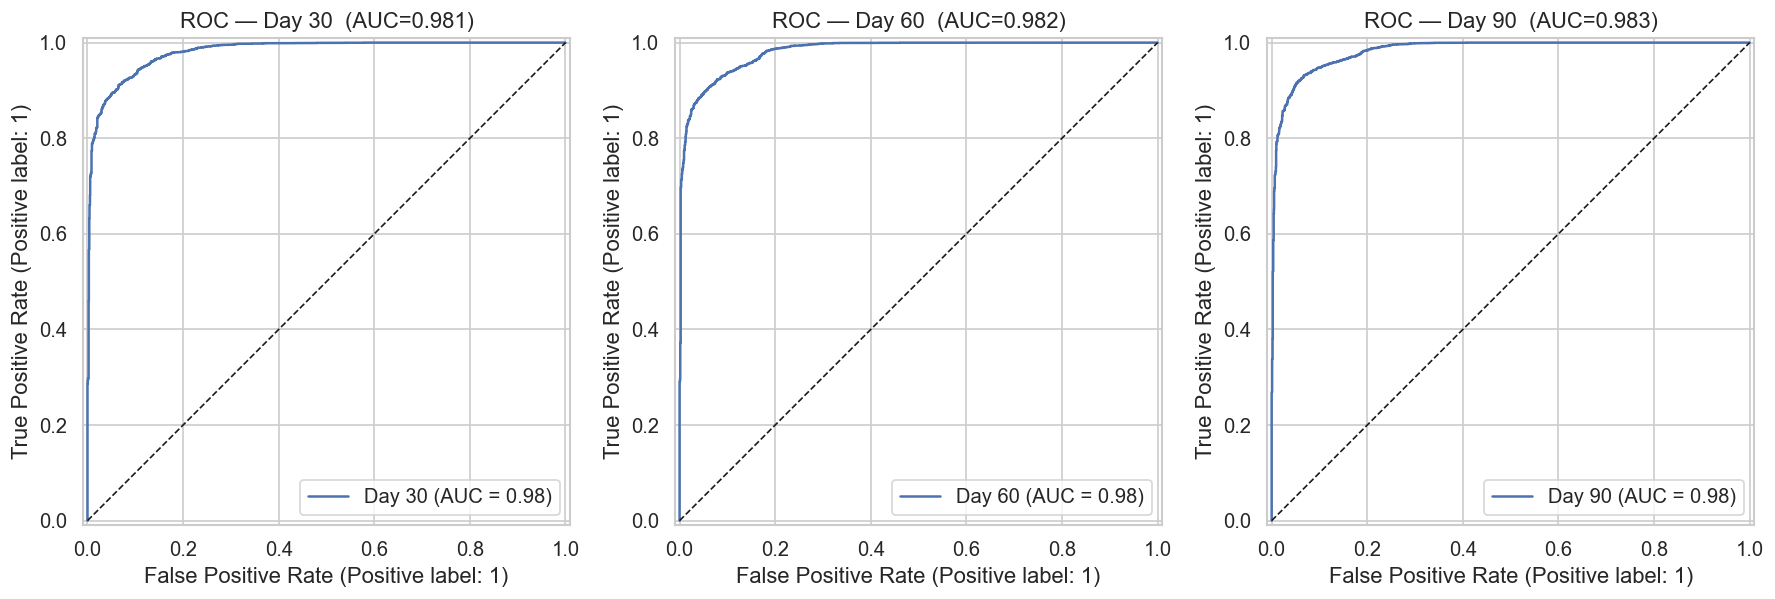

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, CUTOFFS):
    RocCurveDisplay.from_predictions(
        results[n]['y_te'], results[n]['y_proba'], ax=ax,
        name=f'Day {n}'
    )
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'ROC — Day {n}  (AUC={results[n]["auc"]:.3f})')

plt.tight_layout()
plt.savefig(FIGS + 'sim_success_roc_curves.png', bbox_inches='tight')
plt.show()

## 5. Feature importance (day 90)

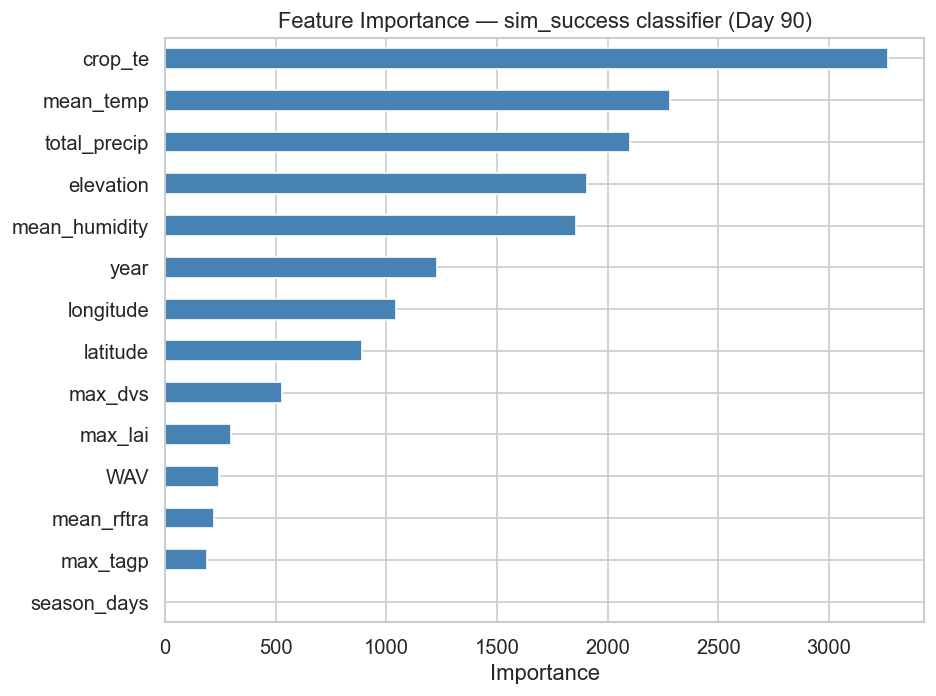

In [7]:
imp = pd.Series(results[90]['model'].feature_importances_,
                index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — sim_success classifier (Day 90)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIGS + 'sim_success_feature_importance.png', bbox_inches='tight')
plt.show()

## 6. Save

In [8]:
for n in CUTOFFS:
    joblib.dump(results[n]['model'],
                OUTPUTS / f'models/sim_success_lgbm_day{n}.joblib')

metrics = {
    str(n): {'auc': round(results[n]['auc'], 4),
             'best_iter': int(results[n]['model'].best_iteration_)}
    for n in CUTOFFS
}
with open(OUTPUTS / 'sim_success_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved.')
print(json.dumps(metrics, indent=2))

Saved.
{
  "30": {
    "auc": 0.981,
    "best_iter": 250
  },
  "60": {
    "auc": 0.9819,
    "best_iter": 231
  },
  "90": {
    "auc": 0.9828,
    "best_iter": 259
  }
}
